# 2 Визуализация данных

**Цель:** Построить ключевые графики.

**Данные:** `data/cian_final_cleaned.csv` (результат очистки из `01_data_cleaning.ipynb`)

2.1 Иморт библиотек

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

2.2 Загрузка очищенного датасета

In [2]:
df = pd.read_csv('../data/cian_final_cleaned.csv')
print("Количество строк и колонок")
print(df.shape)

Количество строк и колонок
(1287, 25)


## 2.3 Распределение цен за квадратный метр

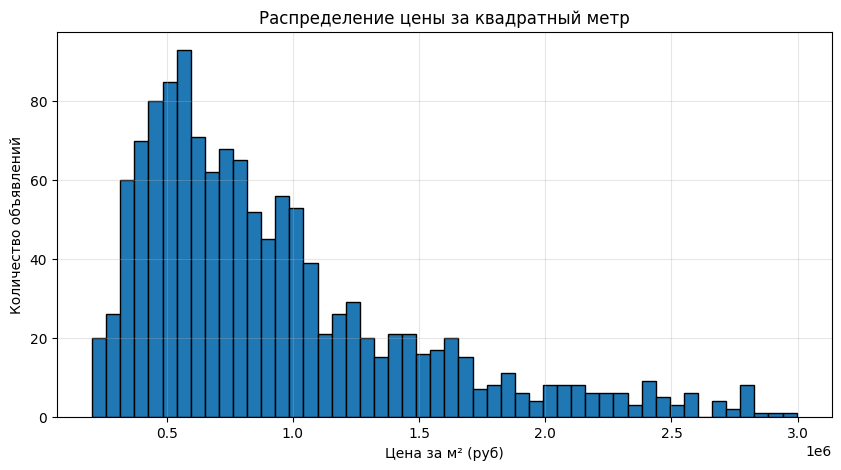

In [3]:
plt.figure(figsize=(10, 5))
plt.hist(df['price_per_m2'], bins=50, edgecolor='black')
plt.title('Распределение цены за квадратный метр')
plt.xlabel('Цена за м² (руб)')
plt.ylabel('Количество объявлений')
plt.grid(True, alpha=0.3)
plt.show()

## 2.4 Зависимость цены от количества комнат

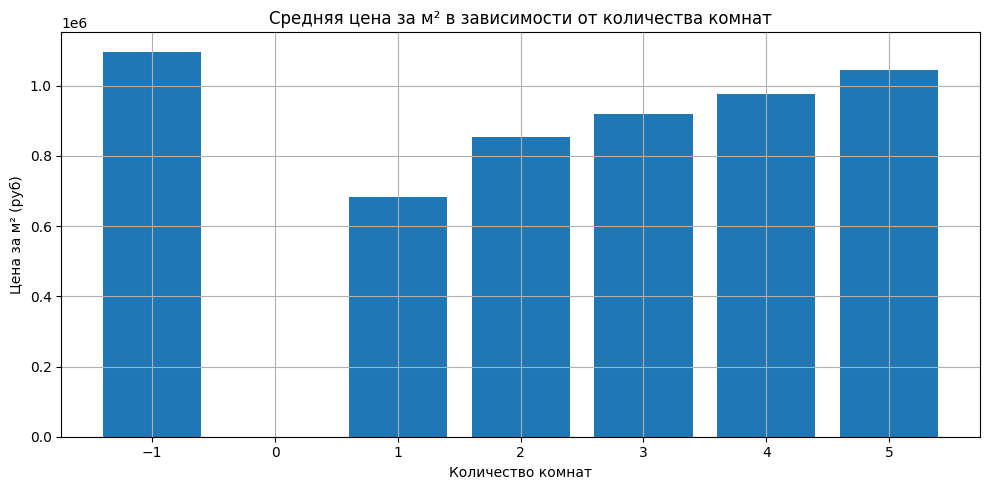


Средняя цена за м² по комнатам:
rooms_count
-1    1096974
 1     681803
 2     852664
 3     919775
 4     975185
 5    1044856
Name: price_per_m2, dtype: int64


In [4]:
rooms_price = df.groupby('rooms_count')['price_per_m2'].mean()

plt.figure(figsize=(10, 5))
plt.bar(rooms_price.index, rooms_price.values)
plt.title('Средняя цена за м² в зависимости от количества комнат')
plt.xlabel('Количество комнат')
plt.ylabel('Цена за м² (руб)')
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nСредняя цена за м² по комнатам:")
print(rooms_price.round(0).astype(int))

## 2.5 Топ-10 самых дорогих районов

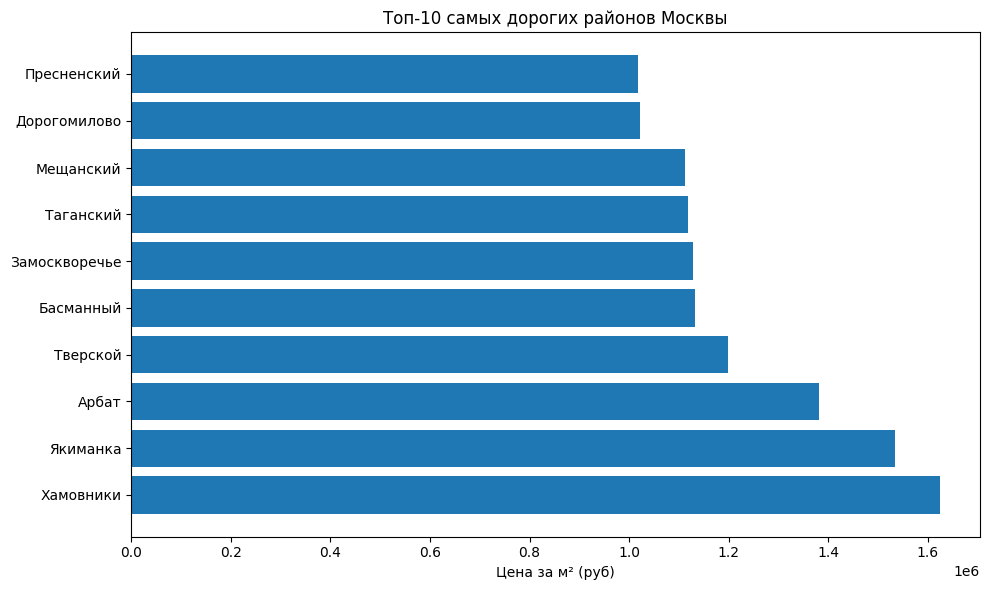


Топ-10 районов по стоимости:
district
Хамовники        1623431
Якиманка         1534524
Арбат            1382048
Тверской         1197538
Басманный        1132112
Замоскворечье    1128847
Таганский        1118021
Мещанский        1112502
Дорогомилово     1020879
Пресненский      1016818
Name: price_per_m2, dtype: int64


In [5]:
top_districts = df.groupby('district')['price_per_m2'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_districts)), top_districts.values)
plt.yticks(range(len(top_districts)), top_districts.index)
plt.xlabel('Цена за м² (руб)')
plt.title('Топ-10 самых дорогих районов Москвы')
plt.tight_layout()
plt.show()

print("\nТоп-10 районов по стоимости:")
print(top_districts.round(0).astype(int))